# dFoF vs locomotion (keta vs control conditions)

In [2]:
import sys, os
import numpy as np
import matplotlib.pylab as plt

from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData

sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_arousal_cond

In [4]:
def load_sessions(session_dict, pupil_threshold=0.29, running_speed_threshold=0.1):
    all_ep = []
    all_HMcond = []

    for file in session_dict['files']:
        data = Data(file, verbose=False)
        data.build_dFoF(verbose=False)
        
        ep = EpisodeData(data,
                         prestim_duration=0,
                         protocol_id=0,
                         quantities=['dFoF', 'running_speed'])
        all_ep.append(ep)

        HMcond = compute_high_arousal_cond(
            ep,
            pupil_threshold=pupil_threshold,
            running_speed_threshold=running_speed_threshold,
            metric='locomotion'
        )
        all_HMcond.append(HMcond)
    
    return all_ep, all_HMcond

In [5]:
def plot_dFoF_locomotion_all(all_episodes_saline, 
                             all_episodes_keta,
                             all_HMcond_saline,
                             all_HMcond_keta,
                             general=True, 
                             active=True, 
                             resting=True):
    
    fig, AX = plt.subplots(2, 2, figsize=(8, 4)) 
    fig.subplots_adjust(hspace=0.8)

    i=0

    for label, all_episodes, all_HMcond, ax_col in [("saline", all_episodes_saline, all_HMcond_saline, 0),
                                                    ("keta", all_episodes_keta, all_HMcond_keta, 1)]:
        
        ep = all_episodes[i]
        HMcond = all_HMcond[i]
    
        if general:
            AX[0][ax_col].plot(ep.t, ep.dFoF[:, :, :].mean(axis=0).mean(axis=0), color='blue') 
            AX[1][ax_col].plot(ep.t, ep.running_speed[:, :].mean(axis=0), color='blue')

        if active:
            mask = HMcond
            print(mask.shape)
            if len(mask) != ep.dFoF.shape[0]:
                print(f"Skipping episode {i}: mask length {len(mask)} != dFoF frames {ep.dFoF.shape[0]}")
                continue  # skip this one

            signal = ep.dFoF[mask].mean(axis=(0, 1))
            if len(signal) == len(ep.t):
                AX[0][ax_col].plot(ep.t, ep.dFoF[HMcond, :, :].mean(axis=0).mean(axis=0), color='orangered') 
                AX[1][ax_col].plot(ep.t, ep.running_speed[HMcond, :].mean(axis=0), color="orangered")
            else:
                print(f"Skipping episode {i}: signal length {len(signal)} != time length {len(ep.t)}")

        if resting:
            mask = ~HMcond
            print(mask.shape)
            if len(mask) != ep.dFoF.shape[0]:
                print(f"Skipping episode {i}: mask length {len(mask)} != dFoF frames {ep.dFoF.shape[0]}")
                continue  # skip this one

            signal = ep.dFoF[mask].mean(axis=(0, 1))
            if len(signal) == len(ep.t):
                AX[0][ax_col].plot(ep.t, ep.dFoF[~HMcond, :, :].mean(axis=0).mean(axis=0), color='grey') 
                AX[1][ax_col].plot(ep.t, ep.running_speed[~HMcond, :].mean(axis=0), color="grey")
            else:
                print(f"Skipping episode {i}: signal length {len(signal)} != time length {len(ep.t)}")

        AX[0][ax_col].set_title(f"dFoF for {label} group n = {len(all_episodes)}")
        AX[1][ax_col].set_title(f"locomotion for {label} group n = {len(all_episodes)}")
        
        i+=1

    AX[0][0].axvspan(0, 2, color='lightgrey')
    AX[0][0].set_ylabel('dFoF')
    AX[0][0].set_xlabel('time (s)')
    AX[0][0].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    AX[1][0].axvspan(0, 2, color='lightgrey')
    AX[1][0].set_ylabel('locomotion (cm/s)')
    AX[1][0].set_xlabel('time (s)')
    AX[1][0].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    AX[0][1].axvspan(0, 2, color='lightgrey')
    AX[0][1].set_ylabel('dFoF')
    AX[0][1].set_xlabel('time (s)')
    AX[0][1].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    AX[1][1].axvspan(0, 2, color='lightgrey')
    AX[1][1].set_ylabel('locomotion (cm/s)')
    AX[1][1].set_xlabel('time (s)')
    AX[1][1].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')
    
    return 0

## Keta vs saline

In [6]:
datafolder_keta = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','NWBs_keta')
SESSIONS_keta = scan_folder_for_NWBfiles(datafolder_keta)
SESSIONS_keta['nwbfiles'] = [os.path.basename(f) for f in SESSIONS_keta['files']]

datafolder_saline = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','NWBs_saline')
SESSIONS_saline = scan_folder_for_NWBfiles(datafolder_saline)
SESSIONS_saline['nwbfiles'] = [os.path.basename(f) for f in SESSIONS_saline['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\NWBs_keta" [...]
 -> found n=15 datafiles (in 9.7s) 
inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\NWBs_saline" [...]
 -> found n=4 datafiles (in 2.6s) 


In [7]:
all_ep_keta, all_HMcond_keta = load_sessions(SESSIONS_keta)
all_ep_saline, all_HMcond_saline = load_sessions(SESSIONS_saline)

  Number of episodes over the whole recording: 240/240 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 240/240 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 240/240 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 240/240 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 304/304 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 240/240 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 197/197 (with protocol condition)
  build

(239,)
(239,)
(240,)
(240,)


0

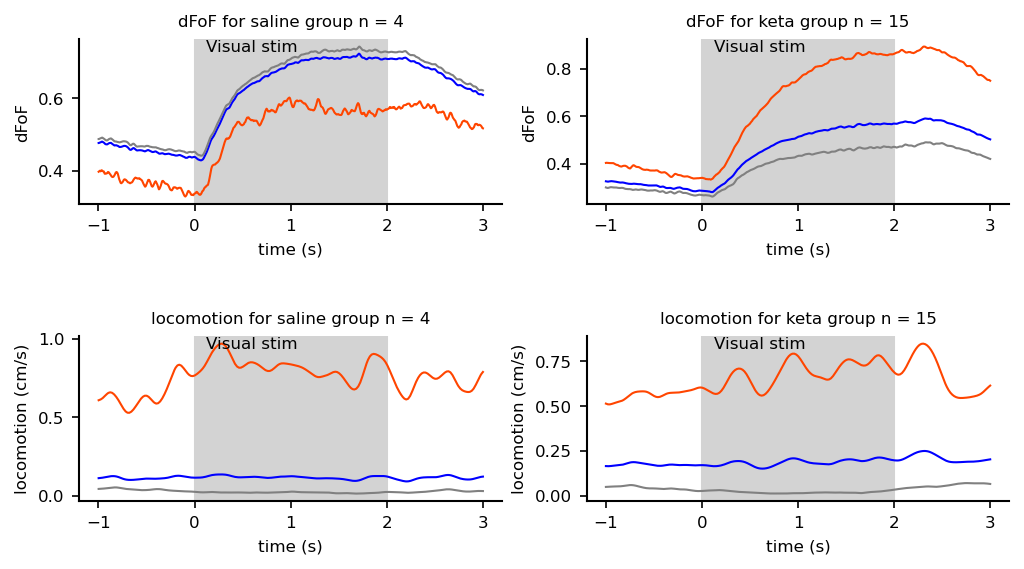

In [8]:
plot_dFoF_locomotion_all(all_ep_saline, 
                         all_ep_keta, 
                         all_HMcond_saline,
                         all_HMcond_keta,
                         general=True, 
                         active=True, 
                         resting=True)